# 1. Build Basic Graph
<small>Demo luồng xử lý Agent RAG với LangGraph (StateGraph, Checkpointer, Router logic).</small>

### 1.1 Import thư viện

In [1]:
import operator
from typing import Annotated, Literal
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.types import Send

### 1.2 State Schemas

In [2]:
class InputState(TypedDict):
    query: str

class InternalState(TypedDict):
    query: str
    documents: Annotated[list[str], operator.add]  # Accumulator: cộng dồn danh sách tài liệu qua các lượt chạy
    answer: str
    evidence_score: float
    retry_count: int
    max_retries: int
    stop_reason: str

class OutputState(TypedDict):
    answer: str
    stop_reason: str

### 1.3 Node Functions

In [3]:
# Giả lập tìm kiếm tài liệu theo query
def retrieve_documents(state: InternalState) -> dict:
    query = state["query"]
    document = f"Retrieved evidence for query: {query}"
    updates = {"documents": [document]}
    if "retry_count" not in state:
        updates["retry_count"] = 0
    if "max_retries" not in state:
        updates["max_retries"] = 3
    return updates

# Chấm điểm độ đầy đủ của tài liệu thu thập được
def evaluate_evidence(state: InternalState) -> dict:
    document_count = len(state.get("documents", []))
    score = min(document_count * 0.4, 1.0)
    return {"evidence_score": score}

# Viết lại query khi chưa đủ bằng chứng và tăng đếm retry
def rewrite_query(state: InternalState) -> dict:
    rewritten_query = state["query"] + " detailed explanation"
    current_retry = state.get("retry_count", 0)
    return {
        "query": rewritten_query,
        "retry_count": current_retry + 1,
    }

# Tổng hợp câu trả lời từ tài liệu đã thu thập
def generate_answer(state: InternalState) -> dict:
    context = "\n".join(state.get("documents", []))
    answer = (
        f"Question: {state['query']}\n\n"
        f"Evidence:\n{context}\n\n"
        "Final answer generated from evidence."
    )
    return {
        "answer": answer,
        "stop_reason": "enough_evidence",
    }

# Trả về thông báo dừng khi vượt quá số lần thử
def generate_fallback(state: InternalState) -> dict:
    return {
        "answer": "Không thu thập đủ bằng chứng sau số lần thử cho phép.",
        "stop_reason": "max_retries_reached",
    }

### 1.4 Router Function

In [4]:
# Điều hướng dựa trên điểm tài liệu và số lần thử
def route_after_evaluation(state: InternalState) -> Literal["generate", "rewrite", "fallback"]:
    evidence_score = state.get("evidence_score", 0.0)
    retry_count = state.get("retry_count", 0)
    max_retries = state.get("max_retries", 3)

    if evidence_score >= 0.7:
        return "generate"
    if retry_count >= max_retries:
        return "fallback"
    return "rewrite"

### 1.5 Build & Compile Graph

In [5]:
builder = StateGraph(InternalState, input_schema=InputState, output_schema=OutputState)

builder.add_node("retrieve", retrieve_documents)
builder.add_node("evaluate", evaluate_evidence)
builder.add_node("rewrite", rewrite_query)
builder.add_node("generate", generate_answer)
builder.add_node("fallback", generate_fallback)

builder.add_edge(START, "retrieve")
builder.add_edge("retrieve", "evaluate")

builder.add_conditional_edges(
    "evaluate",
    route_after_evaluation,
    {
        "generate": "generate",
        "rewrite": "rewrite",
        "fallback": "fallback"
    },
)

builder.add_edge("rewrite", "retrieve")
builder.add_edge("generate", END)
builder.add_edge("fallback", END)

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

### 1.6 Sơ đồ Graph

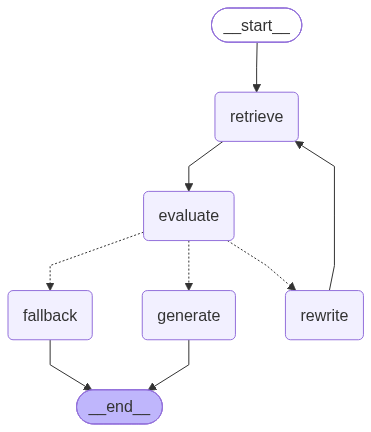

In [6]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    print(graph.get_graph().draw_ascii())

### 1.7 Chạy thử nghiệm Basic Graph

In [7]:
config = {
    "configurable": {"thread_id": "rag-thread-001"},
    "recursion_limit": 20,
}

result = graph.invoke(
    {"query": "LangGraph là gì?"},
    config=config,
)

print(result["answer"])

Question: LangGraph là gì? detailed explanation

Evidence:
Retrieved evidence for query: LangGraph là gì?
Retrieved evidence for query: LangGraph là gì? detailed explanation

Final answer generated from evidence.


# 2. Dynamic Fan Out
<small>Demo mô hình Map-Reduce & Dynamic Fan-Out phân tích tài liệu tài chính sử dụng `Send` API.</small>

### 2.1 State Schemas (OverallState & DocumentWorkerState)

In [8]:
class OverallState(TypedDict):
    # Danh sách tài liệu đầu vào
    documents: list[str]

    # Kết quả từ nhiều worker.
    # Vì nhiều worker cùng ghi vào analyses,
    # chúng ta cần reducer operator.add để nối các list lại.
    analyses: Annotated[list[str], operator.add]

    # Báo cáo cuối cùng
    final_report: str

class DocumentWorkerState(TypedDict):
    # Mỗi worker chỉ cần xử lý một document
    document: str

    # Thêm ID để dễ nhìn thứ tự worker
    document_id: int

### 2.2 Fan-Out Function

In [9]:
def create_workers(
    state: OverallState,
) -> list[Send]:
    """
    Hàm này đọc danh sách documents và tạo động
    một Send cho mỗi document.

    Send gồm:
    - Tên node cần gọi.
    - State riêng truyền cho worker đó.
    """
    sends: list[Send] = []

    for index, document in enumerate(state["documents"]):
        worker_state = {
            "document": document,
            "document_id": index,
        }

        send = Send(
            "analyze_document",
            worker_state,
        )
        sends.append(send)

    print(f"[FAN-OUT] Đã tạo {len(sends)} worker")
    return sends

### 2.3 Map & Reduce Nodes

In [10]:
def analyze_document(
    state: DocumentWorkerState,
) -> dict:
    """
    Mỗi lần node này chạy chỉ xử lý một document.
    Nếu có 3 documents thì node này được gọi 3 lần,
    mỗi lần với một worker state khác nhau.
    """
    document = state["document"]
    document_id = state["document_id"]

    print(f"[MAP] Worker {document_id} đang xử lý: {document}")

    lowercase_document = document.lower()
    if "doanh thu tăng" in lowercase_document:
        analysis = "Tín hiệu tích cực về tăng trưởng doanh thu."
    elif "nợ vay tăng" in lowercase_document:
        analysis = "Rủi ro tài chính tăng do nợ vay gia tăng."
    elif "dòng tiền" in lowercase_document and "âm" in lowercase_document:
        analysis = "Cảnh báo chất lượng lợi nhuận và thanh khoản."
    else:
        analysis = "Chưa xác định được tín hiệu rõ ràng."

    return {
        "analyses": [
            f"Document {document_id}: {analysis}"
        ]
    }

def aggregate_results(
    state: OverallState,
) -> dict:
    """
    Node này chạy sau khi các worker hoàn thành.
    Lúc này state["analyses"] đã được reducer
    gộp từ tất cả output của worker.
    """
    analyses = state["analyses"]
    print(f"[REDUCE] Nhận được {len(analyses)} kết quả")

    report_lines = [
        "BÁO CÁO PHÂN TÍCH",
        "=" * 40,
    ]
    for analysis in analyses:
        report_lines.append(f"- {analysis}")

    final_report = "\n".join(report_lines)
    return {
        "final_report": final_report
    }

### 2.4 Build & Compile Graph

In [11]:
fan_out_builder = StateGraph(OverallState)

fan_out_builder.add_node("analyze_document", analyze_document)
fan_out_builder.add_node("aggregate_results", aggregate_results)

# START không đi vào một node cố định.
# create_workers() trả về list[Send], tạo động nhiều lần gọi analyze_document.
fan_out_builder.add_conditional_edges(START, create_workers, ["analyze_document"])

# Mỗi worker hoàn thành sẽ đi đến aggregate_results.
fan_out_builder.add_edge("analyze_document", "aggregate_results")
fan_out_builder.add_edge("aggregate_results", END)

fan_out_graph = fan_out_builder.compile()

### 2.5 Sơ đồ Graph

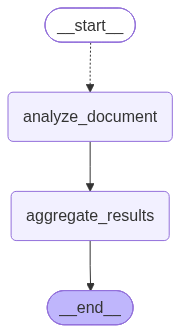

In [12]:
try:
    display(Image(fan_out_graph.get_graph().draw_mermaid_png()))
except Exception:
    print(fan_out_graph.get_graph().draw_ascii())

### 2.6 Invoke & Output

In [13]:
initial_state = {
    "documents": [
        "Doanh thu tăng 20% trong năm nay",
        "Nợ vay tăng mạnh trong quý IV",
        "Dòng tiền hoạt động đang âm",
    ],
    "analyses": [],
    "final_report": "",
}

result = fan_out_graph.invoke(initial_state)
print(result["final_report"])

[FAN-OUT] Đã tạo 3 worker
[MAP] Worker 0 đang xử lý: Doanh thu tăng 20% trong năm nay
[MAP] Worker 1 đang xử lý: Nợ vay tăng mạnh trong quý IV
[MAP] Worker 2 đang xử lý: Dòng tiền hoạt động đang âm
[REDUCE] Nhận được 3 kết quả

BÁO CÁO PHÂN TÍCH
- Document 0: Tín hiệu tích cực về tăng trưởng doanh thu.
- Document 1: Rủi ro tài chính tăng do nợ vay gia tăng.
- Document 2: Cảnh báo chất lượng lợi nhuận và thanh khoản.


# 3. Human-in-the-Loop (HITL) & Interactive State Control
<div style="font-size: 90%; color: #555;">

Demo 3 mô hình tương tác trực tiếp với người dùng qua bàn phím (`input()` API trong Jupyter Notebook):
- **Mô hình 1 (Dynamic Approval):** Node `request_approval` tự động hiển thị thông tin và mở khung nhập `input()` chờ người dùng gõ quyết định phê duyệt (y/n) trực tiếp.
- **Mô hình 2 (State Editing):** Tạm dừng luồng bằng `interrupt_before`, hiển thị trạng thái hiện tại và cho phép người dùng gõ thêm thông tin bổ sung (`input()`), sau đó dùng `update_state()` để cập nhật dữ liệu và tiếp tục luồng.
- **Mô hình 3 (Bank Transfer an toàn):** Áp dụng cơ chế **Idempotency** để tránh giao dịch trùng lặp kết hợp với API `interrupt()` và `Command(resume=..., goto=...)` để xử lý Approve, Edit (sửa số tiền) hoặc Reject (từ chối kèm lý do) từ bàn phím.

</div>

### 3.1 Mô hình 1: Dynamic Approval (Nhập ý kiến người dùng qua `input()`)

In [18]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver

class ApprovalState(TypedDict):
    action: str
    payload: dict
    approved: bool | None
    result: str

def request_approval(state: ApprovalState) -> dict:
    """
    Node này tương tác trực tiếp với người dùng qua hàm input().
    Không dùng dữ liệu mockup, kết quả phê duyệt phụ thuộc hoàn toàn vào bàn phím người dùng.
    """
    print("\n=== [HITL] YÊU CẦU PHÊ DUYỆT HÀNH ĐỘNG ===")
    print(f"- Hành động (Action): {state['action']}")
    print(f"- Nội dung (Payload): {state['payload']}")
    
    user_choice = input("\n--> Bạn có đồng ý cho phép thực thi hành động này không? (y/n): ").strip().lower()
    is_approved = user_choice in ["y", "yes", "có", "1", "đồng ý"]
    
    if is_approved:
        print("[KẾT QUẢ] Người dùng đã ĐỒNG Ý phê duyệt.")
    else:
        print("[KẾT QUẢ] Người dùng đã TỪ CHỐI phê duyệt.")
        
    return {"approved": is_approved}

def route_after_approval(state: ApprovalState) -> str:
    if state.get("approved"):
        return "execute_action"
    return "reject_action"

def execute_action(state: ApprovalState) -> dict:
    return {"result": "[Thành công] Thao tác đã được người dùng phê duyệt và thực thi."}

def reject_action(state: ApprovalState) -> dict:
    return {"result": "[Từ chối] Thao tác đã bị người dùng từ chối."}

In [19]:
# Khởi tạo Graph Builder và lập cấu trúc điều hướng
approval_builder = StateGraph(ApprovalState)
approval_builder.add_node("request_approval", request_approval)
approval_builder.add_node("execute_action", execute_action)
approval_builder.add_node("reject_action", reject_action)

approval_builder.add_edge(START, "request_approval")
approval_builder.add_conditional_edges(
    "request_approval",
    route_after_approval,
    {
        "execute_action": "execute_action",
        "reject_action": "reject_action",
    }
)
approval_builder.add_edge("execute_action", END)
approval_builder.add_edge("reject_action", END)

approval_graph = approval_builder.compile(checkpointer=InMemorySaver())

### 3.2 Sơ đồ Dynamic Approval Graph

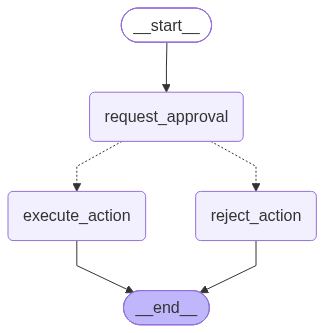

In [20]:
try:
    display(Image(approval_graph.get_graph().draw_mermaid_png()))
except Exception:
    print(approval_graph.get_graph().draw_ascii())

### 3.3 Chạy thử nghiệm Dynamic Approval (Nhập trực tiếp từ bàn phím)

In [21]:
config = {"configurable": {"thread_id": "approval-interactive-001"}}

# Khởi chạy luồng - Node request_approval sẽ gọi input() thật để dừng chờ người dùng nhập
print("=== BẮT ĐẦU THỬ NGHIỆM PHÊ DUYỆT TRỰC TIẾP ===")
final_approval_res = approval_graph.invoke(
    {
        "action": "send_email",
        "payload": {"recipient": "customer@company.com", "subject": "Báo cáo tài chính năm 2026"},
        "approved": None,
        "result": "",
    },
    config=config,
)

print("\n=== KẾT QUẢ CUỐI CÙNG LƯU TRONG STATE ===")
print(final_approval_res["result"])

=== BẮT ĐẦU THỬ NGHIỆM PHÊ DUYỆT TRỰC TIẾP ===

=== [HITL] YÊU CẦU PHÊ DUYỆT HÀNH ĐỘNG ===
- Hành động (Action): send_email
- Nội dung (Payload): {'recipient': 'customer@company.com', 'subject': 'Báo cáo tài chính năm 2026'}
[KẾT QUẢ] Người dùng đã ĐỒNG Ý phê duyệt.

=== KẾT QUẢ CUỐI CÙNG LƯU TRONG STATE ===
[Thành công] Thao tác đã được người dùng phê duyệt và thực thi.


### 3.4 Mô hình 2: State Editing (Chỉnh sửa State trực tiếp qua `update_state` & `input()`)

In [22]:
hitl_graph = fan_out_builder.compile(
    checkpointer=InMemorySaver(),
    interrupt_before=["aggregate_results"]
)

hitl_config = {"configurable": {"thread_id": "hitl-interactive-001"}}
initial_state = {
    "documents": [
        "Doanh thu tăng 20% trong năm nay",
        "Nợ vay tăng mạnh trong quý IV",
        "Dòng tiền hoạt động đang âm",
    ],
    "analyses": [],
    "final_report": "",
}

# 1. Graph chạy 3 Worker song song rồi TẠM DỪNG trước aggregate_results
hitl_graph.invoke(initial_state, config=hitl_config)

# 2. Đọc State tại điểm tạm dừng và hiển thị cho người dùng xem
snapshot = hitl_graph.get_state(hitl_config)
current_analyses = snapshot.values.get("analyses", [])

print("=== KẾT QUẢ PHÂN TÍCH TỰ ĐỘNG CHỜ BẠN DUYỆT ===")
for i, a in enumerate(current_analyses):
    print(f"[{i}] {a}")

# 3. Nhập ý kiến / ghi chú chỉnh sửa trực tiếp từ bàn phím người dùng (không mockup)
user_comment = input("\nNhập ghi chú bổ sung của bạn cho báo cáo này (hoặc bấm Enter để bỏ qua): ").strip()

updated_analyses = list(current_analyses)
if user_comment:
    updated_analyses.append(f"Document [Chuyên gia bổ sung]: {user_comment}")

# 4. Cập nhật State đã có phản hồi của người dùng vào Graph
hitl_graph.update_state(hitl_config, {"analyses": updated_analyses}, as_node="analyze_document")

# 5. Cho phép Graph tiếp tục tạo báo cáo cuối cùng
final_hitl_res = hitl_graph.invoke(None, config=hitl_config)
print("\n=== BÁO CÁO CUỐI CÙNG SAU PHẢN HỒI CỦA NGƯỜI DÙNG ===")
print(final_hitl_res["final_report"])

[FAN-OUT] Đã tạo 3 worker
[MAP] Worker 0 đang xử lý: Doanh thu tăng 20% trong năm nay
[MAP] Worker 1 đang xử lý: Nợ vay tăng mạnh trong quý IV
[MAP] Worker 2 đang xử lý: Dòng tiền hoạt động đang âm
=== KẾT QUẢ PHÂN TÍCH TỰ ĐỘNG CHỜ BẠN DUYỆT ===
[0] Document 0: Tín hiệu tích cực về tăng trưởng doanh thu.
[1] Document 1: Rủi ro tài chính tăng do nợ vay gia tăng.
[2] Document 2: Cảnh báo chất lượng lợi nhuận và thanh khoản.
[REDUCE] Nhận được 7 kết quả

=== BÁO CÁO CUỐI CÙNG SAU PHẢN HỒI CỦA NGƯỜI DÙNG ===
BÁO CÁO PHÂN TÍCH
- Document 0: Tín hiệu tích cực về tăng trưởng doanh thu.
- Document 1: Rủi ro tài chính tăng do nợ vay gia tăng.
- Document 2: Cảnh báo chất lượng lợi nhuận và thanh khoản.
- Document 0: Tín hiệu tích cực về tăng trưởng doanh thu.
- Document 1: Rủi ro tài chính tăng do nợ vay gia tăng.
- Document 2: Cảnh báo chất lượng lợi nhuận và thanh khoản.
- Document [Chuyên gia bổ sung]: hihi


### 3.5 Mô hình 3: Chuyển tiền An toàn (Bank Transfer với Idempotency & Command API)
<small>
Demo quy trình giao dịch ngân hàng có kiểm soát của con người (Human-in-the-Loop):

- **Chuẩn bị (Prepare):** Tạo mã giao dịch duy nhất (idempotency key) từ `transfer_id`.
- **Duyệt giao dịch (Human Approval):** Sử dụng `interrupt()` để gửi thông tin giao dịch ra và chờ phản hồi thực tế từ người dùng (approve / edit / reject).
- **Thực thi (Execute):** Gọi dịch vụ ngân hàng giả lập, áp dụng Idempotency để chống gửi trùng lặp.
- **Hủy (Cancel):** Hủy giao dịch nếu bị từ chối.
</small>

<small><b>Bước 1: Khai báo State & Giả lập dịch vụ Bank hỗ trợ Idempotency</b></small>

In [23]:
from typing import Literal
from typing_extensions import TypedDict
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command, interrupt

# 1. STATE DEFINITION
class TransferState(TypedDict):
    transfer_id: str    
    from_account: str
    to_account: str
    amount: int
    idempotency_key: str
    decision: str
    status: str
    message: str

# 2. GIẢ LẬP HỆ THỐNG CHUYỂN TIỀN (IDEMPOTENCY)
class FakeBankService:
    def __init__(self):
        self.processed_operations: dict[str, dict] = {}

    def transfer(
        self,
        *,
        from_account: str,
        to_account: str,
        amount: int,
        idempotency_key: str,
    ) -> dict:
        if idempotency_key in self.processed_operations:
            print("[BANK] Giao dịch đã tồn tại. Không thực hiện lại.")
            return self.processed_operations[idempotency_key]

        print(f"[BANK] Chuyển {amount:,} đồng từ {from_account} đến {to_account}")
        result = {
            "transaction_id": f"TX-{idempotency_key}",
            "status": "success",
            "amount": amount,
        }
        self.processed_operations[idempotency_key] = result
        return result

bank_service = FakeBankService()

<small><b>Bước 2: Xây dựng các Node nghiệp vụ (Prepare, Execute, Cancel)</b></small>

In [24]:
def prepare_transfer(state: TransferState) -> dict:
    print("[PREPARE] Chuẩn bị giao dịch")
    return {
        "idempotency_key": f"transfer:{state['transfer_id']}",
        "status": "waiting_for_approval",
        "message": "Giao dịch đã được chuẩn bị và đang chờ phê duyệt.",
    }

def execute_transfer(state: TransferState) -> dict:
    print("[EXECUTE] Thực hiện giao dịch")
    result = bank_service.transfer(
        from_account=state["from_account"],
        to_account=state["to_account"],
        amount=state["amount"],
        idempotency_key=state["idempotency_key"],
    )
    return {
        "status": "completed",
        "message": f"Giao dịch hoàn tất. Transaction ID: {result['transaction_id']}",
    }

def cancel_transfer(state: TransferState) -> dict:
    print("[CANCEL] Không thực hiện giao dịch")
    return {"status": "cancelled"}

<small><b>Bước 3: Định nghĩa Human Approval Node hỗ trợ phê duyệt, từ chối và sửa đổi</b></small>

In [25]:
def human_approval(state: TransferState) -> Command[Literal["execute_transfer", "cancel_transfer"]]:
    print("[APPROVAL] Node approval bắt đầu")
    
    # Dừng graph tại interrupt() và trả về thông tin yêu cầu duyệt
    human_response = interrupt({
        "type": "transfer_approval",
        "question": "Bạn có duyệt giao dịch này không?",
        "transfer": {
            "transfer_id": state["transfer_id"],
            "from_account": state["from_account"],
            "to_account": state["to_account"],
            "amount": state["amount"],
        },
        "allowed_actions": ["approve", "edit", "reject"],
    })

    print("[APPROVAL] Nhận phản hồi từ người dùng:", human_response)
    action = human_response.get("action")

    if action == "approve":
        return Command(
            update={
                "decision": "approved",
                "status": "approved",
                "message": "Con người đã phê duyệt giao dịch.",
            },
            goto="execute_transfer",
        )

    if action == "edit":
        edited_amount = human_response.get("amount")
        if not isinstance(edited_amount, int) or edited_amount <= 0:
            return Command(
                update={
                    "decision": "rejected",
                    "status": "cancelled",
                    "message": "Số tiền chỉnh sửa không hợp lệ.",
                },
                goto="cancel_transfer",
            )
        return Command(
            update={
                "amount": edited_amount,
                "decision": "edited_and_approved",
                "status": "approved",
                "message": "Số tiền đã được chỉnh sửa và phê duyệt.",
            },
            goto="execute_transfer",
        )

    reason = human_response.get("reason", "Không có lý do")
    return Command(
        update={
            "decision": "rejected",
            "status": "cancelled",
            "message": f"Giao dịch bị từ chối: {reason}",
        },
        goto="cancel_transfer",
    )

### 3.6 Build & Compile Graph

In [ ]:
transfer_builder = StateGraph(TransferState)
transfer_builder.add_node("prepare_transfer", prepare_transfer)
transfer_builder.add_node("human_approval", human_approval)
transfer_builder.add_node("execute_transfer", execute_transfer)
transfer_builder.add_node("cancel_transfer", cancel_transfer)

transfer_builder.add_edge(START, "prepare_transfer")
transfer_builder.add_edge("prepare_transfer", "human_approval")
transfer_builder.add_edge("execute_transfer", END)
transfer_builder.add_edge("cancel_transfer", END)

transfer_graph = transfer_builder.compile(checkpointer=InMemorySaver())

### 3.7 Sơ đồ Transfer Graph

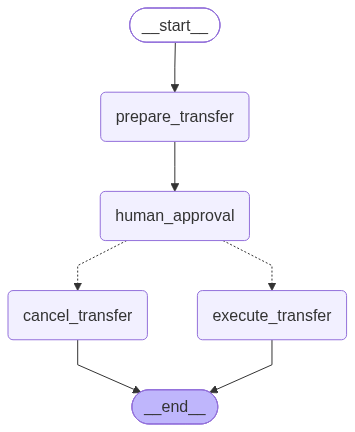

In [27]:
try:
    display(Image(transfer_graph.get_graph().draw_mermaid_png()))
except Exception:
    print(transfer_graph.get_graph().draw_ascii())

### 3.8 Thử nghiệm Tương tác duyệt giao dịch qua bàn phím (`input()` thật)

<small>Bấm Run cell dưới đây để bắt đầu giao dịch và xem thông tin (Graph sẽ chạy đến khi gặp interrupt):</small>

In [30]:
# Cấu hình thread_id duy nhất cho phiên giao dịch
transfer_config = {"configurable": {"thread_id": "transfer-thread-100"}}

initial_transfer_state = {
    "transfer_id": "TRF-999888",
    "from_account": "ACC-MARIA-123",
    "to_account": "ACC-JOHN-456",
    "amount": 500000,
    "idempotency_key": "",
    "decision": "",
    "status": "",
    "message": "",
}

# 1. Khởi chạy đến khi gặp interrupt()
print("=== KHỞI CHẠY GIAO DỊCH ===")
transfer_graph.invoke(initial_transfer_state, config=transfer_config)

# Lấy snapshot từ interrupt và in thông tin
snapshot = transfer_graph.get_state(transfer_config)
if snapshot.next:
    print("\n=== THÔNG TIN GIAO DỊCH ĐANG CHỜ DUYỆT ===")
    print(f"Mã GD: {initial_transfer_state['transfer_id']}")
    print(f"Từ tài khoản: {initial_transfer_state['from_account']}")
    print(f"Đến tài khoản: {initial_transfer_state['to_account']}")
    print(f"Số tiền: {initial_transfer_state['amount']:,} VND")
else:
    print("Không có giao dịch nào đang chờ duyệt.")

=== KHỞI CHẠY GIAO DỊCH ===
[PREPARE] Chuẩn bị giao dịch
[APPROVAL] Node approval bắt đầu

=== THÔNG TIN GIAO DỊCH ĐANG CHỜ DUYỆT ===
Mã GD: TRF-999888
Từ tài khoản: ACC-MARIA-123
Đến tài khoản: ACC-JOHN-456
Số tiền: 500,000 VND


<small>Bấm Run cell dưới đây để gõ phản hồi từ bàn phím (approve/edit/reject) và thực thi tiếp Graph:</small>

In [29]:
snapshot = transfer_graph.get_state(transfer_config)

if snapshot.next:
    # 2. Nhập hành động trực tiếp từ bàn phím
    user_action = input("\nBạn chọn hành động nào? (approve / edit / reject): ").strip().lower()
    
    resume_payload = {}
    if user_action == "approve":
        resume_payload = {"action": "approve"}
    elif user_action == "edit":
        new_amount_str = input("Nhập số tiền mới muốn thay đổi (VND): ").strip()
        try:
            resume_payload = {"action": "edit", "amount": int(new_amount_str)}
        except ValueError:
            print("[LỖI] Số tiền nhập vào phải là số nguyên!")
            resume_payload = {"action": "edit", "amount": 0}
    elif user_action == "reject":
        reason_str = input("Nhập lý do từ chối: ").strip()
        resume_payload = {"action": "reject", "reason": reason_str}
    else:
        print("[CẢNH BÁO] Hành động không hợp lệ! Mặc định là reject.")
        resume_payload = {"action": "reject", "reason": "Không hợp lệ."}

    # 3. Gửi quyết định thực tế qua Command(resume=...)
    print("\n=== TIẾP TỤC LUỒNG THỰC THI GIAO DỊCH ===")
    final_res = transfer_graph.invoke(Command(resume=resume_payload), config=transfer_config)
    
    print("\n=== KẾT QUẢ GIAO DỊCH CUỐI CÙNG ===")
    print(f"Trạng thái (Status): {final_res['status']}")
    print(f"Quyết định (Decision): {final_res['decision']}")
    print(f"Thông báo (Message): {final_res['message']}")
else:
    print("Không có giao dịch nào đang ở trạng thái chờ duyệt để tiếp tục.")


=== TIẾP TỤC LUỒNG THỰC THI GIAO DỊCH ===
[APPROVAL] Node approval bắt đầu
[APPROVAL] Nhận phản hồi từ người dùng: {'action': 'reject', 'reason': 'ko cần'}
[CANCEL] Không thực hiện giao dịch

=== KẾT QUẢ GIAO DỊCH CUỐI CÙNG ===
Trạng thái (Status): cancelled
Quyết định (Decision): rejected
Thông báo (Message): Giao dịch bị từ chối: ko cần


# 4. Checkpointer
<small>Cơ chế lưu trữ trạng thái (State Persistence) và quản lý phiên chạy của Graph trong LangGraph.</small>

<div style="font-size: 90%; color: #555;">

Có thể hình dung như sau:
```text
Thread
└── Checkpoint 1
    └── Checkpoint 2
        └── Checkpoint 3
            └── Checkpoint 4
```

| Khái niệm | Hiểu đơn giản |
| :--- | :--- |
| `Checkpointer` | Bộ phận chịu trách nhiệm lưu/đọc dữ liệu |
| `Checkpoint` | Dữ liệu được lưu tại một thời điểm |
| `StateSnapshot` | Cách LangGraph trình bày một checkpoint cho lập trình viên xem |
| `Thread` | Chuỗi các checkpoint thuộc cùng một workflow/cuộc hội thoại |

</div>

### 4.1 Import thư viện & Khai báo State

In [52]:
from operator import add
from pprint import pprint
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver

# 1. STATE
class State(TypedDict):
    # Field bình thường: update mới ghi đè update cũ
    foo: str
    # Field có reducer: kết quả mới được nối vào list cũ
    bar: Annotated[list[str], add]

### 4.2 Định nghĩa các Node Functions

In [53]:
# 2. NODES
def node_a(state: State) -> dict:
    print("\n[NODE A] state nhận vào:")
    pprint(state)
    return {
        "foo": "a",
        "bar": ["a"],
    }

def node_b(state: State) -> dict:
    print("\n[NODE B] state nhận vào:")
    pprint(state)
    return {
        "foo": "b",
        "bar": ["b"],
    }

### 4.3 Thiết lập cấu trúc Graph

In [54]:
# 3. BUILD GRAPH
builder = StateGraph(State)
builder.add_node("node_a", node_a)
builder.add_node("node_b", node_b)
builder.add_edge(START, "node_a")
builder.add_edge("node_a", "node_b")
builder.add_edge("node_b", END)

### 4.4 Khởi tạo Checkpointer & Biên dịch Graph

In [55]:
# 4. CHECKPOINTER
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

### 4.5 Cấu hình Thread Config

In [56]:
# 5. THREAD CONFIG
config = {
    "configurable": {
        "thread_id": "checkpoint-demo-001"
    }
}

### 4.6 Khởi chạy Graph

In [57]:
# 6. RUN GRAPH
result = graph.invoke(
    {
        "foo": "",
        "bar": [],
    },
    config=config,
)
print("\n\nFINAL RESULT:")
pprint(result)


[NODE A] state nhận vào:
{'bar': [], 'foo': ''}

[NODE B] state nhận vào:
{'bar': ['a'], 'foo': 'a'}


FINAL RESULT:
{'bar': ['a', 'b'], 'foo': 'b'}


### 4.7 Truy vấn trạng thái hiện tại (Latest State Snapshot)

In [58]:
# 7. GET CURRENT/LATEST SNAPSHOT
latest_snapshot = graph.get_state(config)
print("\n\nLATEST SNAPSHOT:")
print(latest_snapshot)



LATEST SNAPSHOT:
StateSnapshot(values={'foo': 'b', 'bar': ['a', 'b']}, next=(), config={'configurable': {'thread_id': 'checkpoint-demo-001', 'checkpoint_ns': '', 'checkpoint_id': '1f1891ce-1687-6423-8002-581b4b7d9e9c'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-07-26T18:07:35.900470+00:00', parent_config={'configurable': {'thread_id': 'checkpoint-demo-001', 'checkpoint_ns': '', 'checkpoint_id': '1f1891ce-1682-6600-8001-947fdc8779bb'}}, tasks=(), interrupts=())


### 4.8 Truy vấn lịch sử các Checkpoint (State History)

##### Bước 1: Lấy danh sách checkpoint lịch sử

In [59]:
# 8. GET ALL CHECKPOINTS
history = list(graph.get_state_history(config))
print(f"\n\nTỔNG CHECKPOINT: {len(history)}")



TỔNG CHECKPOINT: 4


##### Bước 2: Duyệt và in chi tiết từng checkpoint

In [60]:
# get_state_history trả mới nhất trước.
# reversed() giúp in từ cũ đến mới.
for index, snapshot in enumerate(reversed(history)):
    print("\n" + "=" * 70)
    print(f"CHECKPOINT {index}")
    print("=" * 70)
    configurable = snapshot.config.get("configurable", {})
    print("checkpoint_id:", configurable.get("checkpoint_id"))
    print("thread_id:", configurable.get("thread_id"))
    print("checkpoint_ns:", configurable.get("checkpoint_ns"))
    print("created_at:", snapshot.created_at)
    print("next:", snapshot.next)
    print("\nvalues:")
    pprint(snapshot.values)
    print("\nmetadata:")
    pprint(snapshot.metadata)
    print("\nparent_config:")
    pprint(snapshot.parent_config)
    print("\ntasks:")
    if not snapshot.tasks:
        print("Không có task.")
    for task in snapshot.tasks:
        print({
            "id": task.id,
            "name": task.name,
            "error": task.error,
            "interrupts": task.interrupts,
        })
    # API hiện tại có thể expose interrupts trực tiếp trên StateSnapshot.
    print("\nsnapshot.interrupts:", getattr(snapshot, "interrupts", ()))


CHECKPOINT 0
checkpoint_id: 1f1891ce-1673-6ba2-bfff-279826cea702
thread_id: checkpoint-demo-001
checkpoint_ns: 
created_at: 2026-07-26T18:07:35.892470+00:00
next: ('__start__',)

values:
{'bar': []}

metadata:
{'parents': {}, 'source': 'input', 'step': -1}

parent_config:
None

tasks:
{'id': 'a2e58145-206c-93a3-edea-213d2e8191fa', 'name': '__start__', 'error': None, 'interrupts': ()}

snapshot.interrupts: ()

CHECKPOINT 1
checkpoint_id: 1f1891ce-167d-67e2-8000-f455ef18946a
thread_id: checkpoint-demo-001
checkpoint_ns: 
created_at: 2026-07-26T18:07:35.896470+00:00
next: ('node_a',)

values:
{'bar': [], 'foo': ''}

metadata:
{'parents': {}, 'source': 'loop', 'step': 0}

parent_config:
{'configurable': {'checkpoint_id': '1f1891ce-1673-6ba2-bfff-279826cea702',
                  'checkpoint_ns': '',
                  'thread_id': 'checkpoint-demo-001'}}

tasks:
{'id': '4e0d51eb-2fd1-79be-e882-00c6ac80eada', 'name': 'node_a', 'error': None, 'interrupts': ()}

snapshot.interrupts: ()

CHECKP

### 4.9 Basic Code for Viewing Checkpoint
<small>Hướng dẫn chi tiết các câu lệnh Python cơ bản để truy vấn trạng thái hiện tại và xem lịch sử các checkpoint (State History) của một Thread trong LangGraph.</small>

##### Bước 1: Khởi chạy Graph và tạo các Checkpoint lịch sử

In [61]:
# Cấu hình thread_id mới để chạy thử nghiệm xem Checkpoint
view_config = {"configurable": {"thread_id": "view-thread-001"}}

# Khởi chạy Graph (chuyển tiền) lần đầu tiên (luồng sẽ tự dừng tại Node human_approval)
initial_state = {
    "transfer_id": "TRF-777777",
    "from_account": "ACC-ALICE-888",
    "to_account": "ACC-BOB-999",
    "amount": 150000,
    "idempotency_key": "",
    "decision": "",
    "status": "",
    "message": "",
}
print("=== KHỞI CHẠY GIAO DỊCH LẦN ĐẦU ===")
transfer_graph.invoke(initial_state, config=view_config)
print("Graph đã chạy Node prepare_transfer và đang tạm dừng tại human_approval.")

=== KHỞI CHẠY GIAO DỊCH LẦN ĐẦU ===
[PREPARE] Chuẩn bị giao dịch
[APPROVAL] Node approval bắt đầu
Graph đã chạy Node prepare_transfer và đang tạm dừng tại human_approval.


##### Bước 2: Xem trạng thái hiện tại (State Snapshot) từ Checkpoint mới nhất

In [62]:
# Lấy trạng thái hiện tại (State Snapshot) của thread
current_state = transfer_graph.get_state(view_config)
print("=== TRẠNG THÁI HIỆN TẠI (LATEST SNAPSHOT) ===")
print("Values (Giá trị State hiện tại):", current_state.values)
print("Next Node (Node tiếp theo sẽ chạy):", current_state.next)
print("Checkpoint ID hiện tại:", current_state.config["configurable"]["checkpoint_id"])

=== TRẠNG THÁI HIỆN TẠI (LATEST SNAPSHOT) ===
Values (Giá trị State hiện tại): {'transfer_id': 'TRF-777777', 'from_account': 'ACC-ALICE-888', 'to_account': 'ACC-BOB-999', 'amount': 150000, 'idempotency_key': 'transfer:TRF-777777', 'decision': '', 'status': 'waiting_for_approval', 'message': 'Giao dịch đã được chuẩn bị và đang chờ phê duyệt.'}
Next Node (Node tiếp theo sẽ chạy): ('human_approval',)
Checkpoint ID hiện tại: 1f1891ce-1706-6657-8007-24b08db159df


##### Bước 3: Xem lịch sử tất cả các Checkpoint của Thread (State History)

In [63]:
print("=== LỊCH SỬ CÁC CHECKPOINT (STATE HISTORY) ===")
# Duyệt qua lịch sử các phiên lưu checkpoint từ mới nhất đến cũ nhất
for state_history in transfer_graph.get_state_history(view_config):
    print("-" * 60)
    print(f"Checkpoint ID: {state_history.config['configurable']['checkpoint_id']}")
    print(f"Node vừa chạy: {state_history.metadata.get('source')}")
    print(f"Giá trị State lúc đó: {state_history.values}")
    print(f"Node tiếp theo: {state_history.next}")

=== LỊCH SỬ CÁC CHECKPOINT (STATE HISTORY) ===
------------------------------------------------------------
Checkpoint ID: 1f1891ce-1706-6657-8007-24b08db159df
Node vừa chạy: loop
Giá trị State lúc đó: {'transfer_id': 'TRF-777777', 'from_account': 'ACC-ALICE-888', 'to_account': 'ACC-BOB-999', 'amount': 150000, 'idempotency_key': 'transfer:TRF-777777', 'decision': '', 'status': 'waiting_for_approval', 'message': 'Giao dịch đã được chuẩn bị và đang chờ phê duyệt.'}
Node tiếp theo: ('human_approval',)
------------------------------------------------------------
Checkpoint ID: 1f1891ce-1703-6f46-8006-363ca04b4641
Node vừa chạy: loop
Giá trị State lúc đó: {'transfer_id': 'TRF-777777', 'from_account': 'ACC-ALICE-888', 'to_account': 'ACC-BOB-999', 'amount': 150000, 'idempotency_key': '', 'decision': '', 'status': '', 'message': ''}
Node tiếp theo: ('prepare_transfer',)
------------------------------------------------------------
Checkpoint ID: 1f1891ce-1701-6848-8005-e9b05c15196c
Node vừa chạ

# 5. Memory

### 5.1 Basic Short-term memory

##### Bước 1: Import thư viện & Định nghĩa Node

In [1]:
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import (
    StateGraph,
    START,
    END,
    MessagesState,
)

# 1. NODE
def reply_node(state: MessagesState) -> dict:
    """
    state["messages"] chứa toàn bộ message history
    đã được lưu trong thread hiện tại.
    """
    human_messages = [
        message.content
        for message in state["messages"]
        if message.type == "human"
    ]
    first_message = (
        human_messages[0]
        if human_messages
        else "Chưa có tin nhắn"
    )
    answer = (
        f"Thread này hiện có "
        f"{len(human_messages)} tin nhắn từ user. "
        f"Tin nhắn đầu tiên là: {first_message}"
    )
    # Chỉ trả message mới.
    # MessagesState sử dụng add_messages reducer
    # để thêm nó vào message history.
    return {
        "messages": [
            {
                "role": "assistant",
                "content": answer,
            }
        ]
    }

##### Bước 2: Thiết lập cấu trúc Graph

In [2]:
# 2. BUILD GRAPH
builder = StateGraph(MessagesState)
builder.add_node("reply", reply_node)
builder.add_edge(START, "reply")
builder.add_edge("reply", END)

##### Bước 3: Khởi tạo Checkpointer & Biên dịch Graph

In [3]:
# 3. CHECKPOINTER
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

##### Bước 4: Định nghĩa Hàm Helper

In [4]:
# 4. HELPER
def print_last_message(result: dict) -> None:
    msg = result["messages"][-1]
    print(msg.get("content") if isinstance(msg, dict) else msg.content)


##### Bước 5: Thử nghiệm lưu trạng thái trên cùng một Thread

In [5]:
# 5. SAME THREAD
thread_a = {
    "configurable": {
        "thread_id": "thread-A"
    }
}

result_1 = graph.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "Tên tôi là An",
            }
        ]
    },
    config=thread_a,
)
print_last_message(result_1)

result_2 = graph.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "Tin nhắn đầu tiên của tôi là gì?",
            }
        ]
    },
    config=thread_a,
)
print_last_message(result_2)

Thread này hiện có 1 tin nhắn từ user. Tin nhắn đầu tiên là: Tên tôi là An
Thread này hiện có 2 tin nhắn từ user. Tin nhắn đầu tiên là: Tên tôi là An


##### Bước 6: Xem short-term memory đang lưu gì

In [6]:
from pprint import pprint

snapshot = graph.get_state(thread_a)
print("STATE HIỆN TẠI:")
pprint(snapshot.values)
print("\nNODE TIẾP THEO:")
pprint(snapshot.next)
print("\nCHECKPOINT CONFIG:")
pprint(snapshot.config)

STATE HIỆN TẠI:
{'messages': [HumanMessage(content='Tên tôi là An', additional_kwargs={}, response_metadata={}, id='130a343a-efc2-4ef4-910d-bc664e31c24a'),
              AIMessage(content='Thread này hiện có 1 tin nhắn từ user. Tin nhắn đầu tiên là: Tên tôi là An', additional_kwargs={}, response_metadata={}, id='98d7ccef-c91a-4607-9f0c-a5d485510d36', tool_calls=[], invalid_tool_calls=[]),
              HumanMessage(content='Tin nhắn đầu tiên của tôi là gì?', additional_kwargs={}, response_metadata={}, id='98a83c22-7a33-4db9-81e6-99ae7004ab36'),
              AIMessage(content='Thread này hiện có 2 tin nhắn từ user. Tin nhắn đầu tiên là: Tên tôi là An', additional_kwargs={}, response_metadata={}, id='5b2c41aa-2661-4375-8c84-9535d05cb928', tool_calls=[], invalid_tool_calls=[])]}

NODE TIẾP THEO:
()

CHECKPOINT CONFIG:
{'configurable': {'checkpoint_id': '1f189695-8fc2-6c20-8004-b3e175767d7e',
                  'checkpoint_ns': '',
                  'thread_id': 'thread-A'}}


##### Bước 7: Khởi tạo cấu hình cho Thread mới (thread-B)

In [ ]:
# 6. DIFFERENT THREAD
# Hãy thử thay đổi thread_id từ "thread-B" thành "thread-A" để thấy sự khác biệt:
# - Nếu dùng "thread-B": Hệ thống sẽ khởi tạo một luồng hội thoại hoàn toàn mới (cô lập).
# - Nếu đổi lại thành "thread-A": Hệ thống sẽ nhận diện cuộc hội thoại cũ đã lưu và nhớ tên bạn.
thread_b = {
    "configurable": {
        "thread_id": "thread-B"  # Thử đổi giá trị này thành "thread-A" và chạy lại để xem kết quả
    }
}


##### Bước 8: Gửi câu hỏi đến Thread mới để kiểm tra tính cô lập của bộ nhớ

In [ ]:
result = graph.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "Tin nhắn đầu tiên của tôi là gì?",
            }
        ]
    },
    config=thread_b,
)

print_last_message(result)


### 5.2 Basic long-term memory

<div style="font-size: 90%; color: #555;">

**Long-term memory** sử dụng **Store** (`InMemoryStore`) để lưu dữ liệu người dùng độc lập với phiên chat (`thread_id`).

Các toán tử chính:
- `put(ns, key, val)`: Lưu/Cập nhật dữ liệu.
- `get(ns, key)`: Đọc bản ghi cụ thể.
- `search(ns)`: Tìm kiếm trong namespace.
- `delete(ns, key)`: Xóa dữ liệu.
- `list_namespaces()`: Liệt kê các namespace.

</div>

##### Bước 1: Import thư viện & Định nghĩa Context Schema

In [1]:
from dataclasses import dataclass
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.runtime import Runtime
from langgraph.store.memory import InMemoryStore

@dataclass
class Context:
    user_id: str

# Hàm Helper in tin nhắn cuối cùng từ result
def print_last_message(result: dict) -> None:
    msg = result["messages"][-1]
    print(msg.get("content") if isinstance(msg, dict) else msg.content)


##### Bước 2: Định nghĩa Node Function (Đọc/Ghi Long-term Memory)

In [2]:
def memory_node(state: MessagesState, runtime: Runtime[Context]) -> dict:
    user_id = runtime.context.user_id
    namespace = ("users", user_id, "profile")
    
    last_message = state["messages"][-1].content.strip()
    lower_message = last_message.lower()

    # 1. GHI MEMORY
    if lower_message.startswith("remember:"):
        memory_text = last_message.split(":", 1)[1].strip()
        runtime.store.put(namespace, "main-preference", {"text": memory_text})
        answer = f"Đã lưu vào long-term memory: {memory_text}"

    # 2. ĐỌC MEMORY
    elif lower_message in {"what do you remember?", "bạn nhớ gì về tôi?"}:
        item = runtime.store.get(namespace, "main-preference")
        if item is None:
            answer = "Tôi chưa có long-term memory nào về bạn."
        else:
            answer = f"Tôi đang nhớ rằng: {item.value['text']}"
    else:
        answer = "Bạn có thể dùng:\n- remember: ...\n- bạn nhớ gì về tôi?"

    return {
        "messages": [
            {"role": "assistant", "content": answer}
        ]
    }


##### Bước 3: Thiết lập cấu trúc Graph

In [3]:
builder = StateGraph(MessagesState, context_schema=Context)
builder.add_node("memory", memory_node)
builder.add_edge(START, "memory")
builder.add_edge("memory", END)

##### Bước 4: Khởi tạo Checkpointer, Store & Biên dịch Graph

In [4]:
checkpointer = InMemorySaver()
store = InMemoryStore()
graph = builder.compile(checkpointer=checkpointer, store=store)


##### Bước 5: Thử nghiệm ghi nhớ thông tin (Ghi Memory)

In [5]:
config = {
    "configurable": {
        "thread_id": "thread-1"
    }
}
context = Context(user_id="user-123")

# Ghi thông tin cần nhớ vào bộ nhớ dài hạn (Long-term Store)
result = graph.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "remember: Tôi thích lập trình Python và xây dựng AI Agent"
            }
        ]
    },
    config=config,
    context=context,
)
print_last_message(result)


Đã lưu vào long-term memory: Tôi thích lập trình Python và xây dựng AI Agent


##### Bước 6: Thử nghiệm truy vấn thông tin trên Thread khác (Đọc Memory)

In [6]:
# Sử dụng một thread_id hoàn toàn mới (thread-2) nhưng giữ nguyên user_id
# Điều này chứng minh Long-term memory hoạt động độc lập với Thread ID (khác với Short-term memory)
new_config = {
    "configurable": {
        "thread_id": "thread-2"
    }
}

result = graph.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "bạn nhớ gì về tôi?"
            }
        ]
    },
    config=new_config,
    context=context,
)
print_last_message(result)


Tôi đang nhớ rằng: Tôi thích lập trình Python và xây dựng AI Agent


##### Bước 7: Tìm kiếm (Search) tất cả thông tin đã lưu trong Store theo Namespace

<small>Phương thức `store.search(namespace)` giúp bạn quét qua toàn bộ namespace được chỉ định để lấy ra danh sách các bản ghi (kèm theo key, value và thông tin namespace cụ thể).</small>


In [7]:
namespace = ("users", "user-001", "profile")
items = store.search(namespace)

for item in items:
    print("Key:", item.key)
    print("Value:", item.value)
    print("Namespace:", item.namespace)
    print("-" * 30)


##### Bước 8: Đọc trực tiếp (Get) thông tin của một Key cụ thể từ Store

<small>Phương thức `store.get(namespace, key)` được dùng khi bạn biết chính xác key cần tìm (ví dụ: `main-preference`), giúp truy xuất trực tiếp dữ liệu với hiệu năng tối ưu.</small>


In [8]:
item = store.get(namespace, "main-preference")
if item:
    print(item.value)


##### Bước 9: Kiểm tra lại thông tin đã đọc từ Store

In [9]:
item = store.get(namespace, "main-preference")
if item:
    print(item.value)


### 5.3 Semantic search in Store

In [10]:
data = {
    "memory-1": {
        "text": "Người dùng rất thích ăn pizza và các món ăn đặc trưng của Ý",
        "type": "food_preference",
    },
    "memory-2": {
        "text": "Người dùng hiện đang làm việc ở vị trí kế toán trưởng tại một công ty tài chính lớn",
        "type": "occupation",
    },
    "memory-3": {
        "text": "Người dùng có thói quen đi du lịch nghỉ dưỡng ở Đà Lạt vào các dịp cuối tuần",
        "type": "travel_preference",
    },
    "memory-4": {
        "text": "Người dùng đang tự học lập trình ngôn ngữ Python nâng cao và phát triển AI Agent với thư viện LangGraph",
        "type": "skill_learning",
    },
    "memory-5": {
        "text": "Người dùng có khẩu vị đặc biệt và không thích ăn bất cứ món ăn nào có chứa nhiều hành tây",
        "type": "food_dislike",
    }
}


In [ ]:
# %pip install langchain-huggingface && sentence-transformers


In [ ]:
from langchain_huggingface import HuggingFaceEmbeddings
from langgraph.store.memory import InMemoryStore

# Khởi tạo mô hình Embeddings của OpenAI
embeddings = HuggingFaceEmbeddings(model_name="AITeamVN/Vietnamese_Embedding")

# Khởi tạo Store hỗ trợ Vector Search
store = InMemoryStore(
    index={
        "embed": embeddings,
        "dims": 1536,
        "fields": ["text"],  # Chỉ vector hóa trường "text"
    }
)

namespace = ("users", "user-001", "memories")

# Sử dụng vòng lặp duyệt qua data để put thông tin nhanh hơn
for key, val in data.items():
    store.put(namespace, key, val)

# Tìm kiếm ngữ nghĩa bằng câu truy vấn tiếng Việt
results = store.search(
    namespace,
    query="Người dùng thích ăn món gì?",
    limit=2,
)

In [14]:
for item in results:
    print(item.value)
    print("Score:", item.score)

{'text': 'Người dùng rất thích ăn pizza và các món ăn đặc trưng của Ý', 'type': 'food_preference'}
Score: 0.7046820105619224
{'text': 'Người dùng có khẩu vị đặc biệt và không thích ăn bất cứ món ăn nào có chứa nhiều hành tây', 'type': 'food_dislike'}
Score: 0.5049545879455876


##### Bước 11: Định nghĩa Node tích hợp bộ nhớ dài hạn vào LLM Prompt (Call Model)

In [15]:
def call_model(state: MessagesState, runtime: Runtime[Context]) -> dict:
    namespace = ("users", runtime.context.user_id, "memories")
    user_query = state["messages"][-1].content

    # Tìm kiếm các ký ức liên quan ngữ nghĩa trong Store
    memories = runtime.store.search(namespace, query=user_query, limit=3)
    memory_text = "\n".join(item.value["text"] for item in memories)

    system_message = {
        "role": "system",
        "content": f"Use the following user memories when relevant:\n{memory_text}"
    }

    response = model.invoke([system_message] + state["messages"])
    return {"messages": [response]}


### 5.4 Quản lý message memory dài

Ba chiến lược được dùng nhiều nhất để quản lý bộ nhớ tin nhắn khi cuộc hội thoại kéo dài:

<small>

- **Trim**: Cắt tỉa bớt tin nhắn cũ trước khi truyền vào LLM Prompt (giữ nguyên lịch sử gốc trong Checkpointer).
- **Delete**: Xóa vĩnh viễn tin nhắn khỏi Checkpoint State bằng đối tượng `RemoveMessage` của LangGraph.
- **Summarize**: Tóm tắt cuộc hội thoại cũ thành nội dung ngắn gọn và xóa các tin nhắn thô đã tóm tắt.
</small>

##### Bước 1: Chiến lược Trim (Cắt tỉa tin nhắn trước khi truyền vào LLM Prompt)

<small>Hàm `trim_messages` chỉ lấy ra 4 tin nhắn gần nhất để đưa vào Prompt, trong khi Checkpointer vẫn lưu trữ toàn bộ lịch sử thô.</small>

In [27]:
from langchain_core.messages import HumanMessage, AIMessage, trim_messages
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.checkpoint.memory import InMemorySaver

# 1. Giả lập hàm gọi LLM
def mock_llm_invoke(messages):
    return AIMessage(content=f"Đã xử lý dựa trên {len(messages)} tin nhắn được cắt tỉa trong prompt.")

# 2. Node thực hiện Trim
def trim_node(state: MessagesState) -> dict:
    full_messages = state["messages"]

    # Cắt tỉa tin nhắn cho LLM Prompt
    model_messages = trim_messages(
        full_messages,
        strategy="last",     # "last": lấy tin nhắn mới nhất | "first": lấy tin nhắn đầu tiên
        token_counter=len,   # len: đếm số tin nhắn (hoặc dùng count_tokens_approximately/model)
        max_tokens=4,        # Giới hạn tối đa số tin nhắn / token được giữ lại
        start_on="human",    # Luôn bắt đầu bằng HumanMessage để LLM không bị bối rối
        include_system=True, # Giữ lại SystemMessage ở đầu bất kể vị trí cắt tỉa
        allow_partial=False, # True: cắt lẻ chữ trong msg | False: giữ nguyên vẹn msg
    )

    print(f"--- [TRIM DEMO] ---")
    print(f"Tổng số tin nhắn trong Checkpoint State: {len(full_messages)}")
    print(f"Số tin nhắn thực tế gửi vào LLM Prompt: {len(model_messages)}")
    print("Chi tiết tin nhắn gửi vào LLM:")
    for msg in model_messages:
        print(f"  [{msg.type.upper()}]: {msg.content}")

    response = mock_llm_invoke(model_messages)
    return {"messages": [response]}

# 3. Xây dựng & Biên dịch Graph cho Trim
builder_trim = StateGraph(MessagesState)
builder_trim.add_node("trim_node", trim_node)
builder_trim.add_edge(START, "trim_node")
builder_trim.add_edge("trim_node", END)

graph_trim = builder_trim.compile(checkpointer=InMemorySaver())


In [28]:
# Mockup Data & Thử nghiệm chạy Trim Graph
config_trim = {"configurable": {"thread_id": "trim-thread-1"}}

mock_questions = [
    "Xin chào, tôi cần tư vấn mua laptop.",
    "Tôi muốn mua máy làm lập trình Python và AI Agent.",
    "Giá của dòng máy đó khoảng bao nhiêu?",
    "Có hỗ trợ trả góp 0% không bạn?",
    "Cửa hàng của bạn ở đâu tại Hà Nội?",
    "Chính sách bảo hành như thế nào?",
]

for q in mock_questions:
    print(f">>> USER: {q}")
    res = graph_trim.invoke({"messages": [HumanMessage(content=q)]}, config=config_trim)
    print(f"BOT: {res['messages'][-1].content}")


>>> USER: Xin chào, tôi cần tư vấn mua laptop.
--- [TRIM DEMO] ---
Tổng số tin nhắn trong Checkpoint State: 1
Số tin nhắn thực tế gửi vào LLM Prompt: 1
Chi tiết tin nhắn gửi vào LLM:
  [HUMAN]: Xin chào, tôi cần tư vấn mua laptop.
BOT: Đã xử lý dựa trên 1 tin nhắn được cắt tỉa trong prompt.
>>> USER: Tôi muốn mua máy làm lập trình Python và AI Agent.
--- [TRIM DEMO] ---
Tổng số tin nhắn trong Checkpoint State: 3
Số tin nhắn thực tế gửi vào LLM Prompt: 3
Chi tiết tin nhắn gửi vào LLM:
  [HUMAN]: Xin chào, tôi cần tư vấn mua laptop.
  [AI]: Đã xử lý dựa trên 1 tin nhắn được cắt tỉa trong prompt.
  [HUMAN]: Tôi muốn mua máy làm lập trình Python và AI Agent.
BOT: Đã xử lý dựa trên 3 tin nhắn được cắt tỉa trong prompt.
>>> USER: Giá của dòng máy đó khoảng bao nhiêu?
--- [TRIM DEMO] ---
Tổng số tin nhắn trong Checkpoint State: 5
Số tin nhắn thực tế gửi vào LLM Prompt: 3
Chi tiết tin nhắn gửi vào LLM:
  [HUMAN]: Tôi muốn mua máy làm lập trình Python và AI Agent.
  [AI]: Đã xử lý dựa trên 3 ti

##### Bước 2: Chiến lược Delete (Xóa vĩnh viễn tin nhắn cũ bằng RemoveMessage)

<small>Node `delete_old_messages` phát lệnh `RemoveMessage` để giữ lại tối đa 4 tin nhắn mới nhất trong Checkpointer.</small>

In [29]:
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage, AIMessage, RemoveMessage

def chatbot_node(state: MessagesState) -> dict:
    return {"messages": [AIMessage(content="Đã ghi nhận tin nhắn.")]}

def delete_old_messages(state: MessagesState) -> dict:
    messages = state["messages"]
    if len(messages) <= 4:
        return {}

    # Giữ lại 4 tin nhắn mới nhất, tạo RemoveMessage xóa toàn bộ tin nhắn cũ hơn
    old_messages = messages[:-4]
    print(f"--- [DELETE DEMO] Đã phát lệnh RemoveMessage xóa {len(old_messages)} tin nhắn cũ ---")
    return {
        "messages": [RemoveMessage(id=msg.id) for msg in old_messages]
    }

# Xây dựng & Biên dịch Graph cho Delete
builder_del = StateGraph(MessagesState)
builder_del.add_node("chatbot", chatbot_node)
builder_del.add_node("delete_old", delete_old_messages)

builder_del.add_edge(START, "chatbot")
builder_del.add_edge("chatbot", "delete_old")
builder_del.add_edge("delete_old", END)

graph_del = builder_del.compile(checkpointer=InMemorySaver())


In [30]:
# Mockup Data & Thử nghiệm chạy Delete Graph
config_del = {"configurable": {"thread_id": "delete-thread-1"}}

# Gửi liên tiếp 6 tin nhắn thử nghiệm
for i in range(1, 7):
    print(f">>> Gửi tin nhắn {i}")
    graph_del.invoke({"messages": [HumanMessage(content=f"Tin nhắn số {i}")]}, config=config_del)

# Kiểm tra số tin nhắn còn lại trong Checkpoint State
snapshot_del = graph_del.get_state(config_del)
print(f"\n=> TỔNG SỐ MESSAGES THỰC TẾ TRONG CHECKPOINT: {len(snapshot_del.values['messages'])}")


>>> Gửi tin nhắn 1
>>> Gửi tin nhắn 2
>>> Gửi tin nhắn 3
--- [DELETE DEMO] Đã phát lệnh RemoveMessage xóa 2 tin nhắn cũ ---
>>> Gửi tin nhắn 4
--- [DELETE DEMO] Đã phát lệnh RemoveMessage xóa 2 tin nhắn cũ ---
>>> Gửi tin nhắn 5
--- [DELETE DEMO] Đã phát lệnh RemoveMessage xóa 2 tin nhắn cũ ---
>>> Gửi tin nhắn 6
--- [DELETE DEMO] Đã phát lệnh RemoveMessage xóa 2 tin nhắn cũ ---

=> TỔNG SỐ MESSAGES THỰC TẾ TRONG CHECKPOINT: 4


##### Bước 3: Chiến lược Summarize (Tóm tắt cuộc hội thoại cũ & dọn dẹp tin nhắn thô)

<small>Node `summarize_node` sẽ tự động tóm tắt các tin nhắn cũ thành chuỗi `summary` và phát lệnh `RemoveMessage` dọn dẹp các tin nhắn thô đã tóm tắt.</small>

In [32]:
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage, AIMessage, RemoveMessage

class SummaryState(MessagesState):
    summary: str

# Node kiểm tra và tóm tắt nếu lịch sử hội thoại quá dài
def summarize_node(state: SummaryState) -> dict:
    messages = state["messages"]
    if len(messages) <= 4:
        return {}

    # Giữ lại 2 tin nhắn mới nhất, tóm tắt phần các tin nhắn cũ hơn
    to_summarize = messages[:-2]
    existing_summary = state.get("summary", "")

    # Tóm tắt ngữ nghĩa (Lọc các câu hỏi/thông tin chính từ User, bỏ qua câu trả lời thô của Bot)
    human_inputs = [m.content for m in to_summarize if m.type == "human"]
    new_notes = ", ".join(human_inputs)
    
    if existing_summary:
        updated_summary = f"{existing_summary}; {new_notes}"
    else:
        updated_summary = f"Thông tin người dùng đã chia sẻ: {new_notes}"

    print(f"--- [SUMMARIZE DEMO] Đã tóm tắt {len(to_summarize)} tin nhắn cũ ---")
    print(f"--- [BẢN TÓM TẮT MỚI]: {updated_summary}")

    return {
        "summary": updated_summary,
        "messages": [RemoveMessage(id=m.id) for m in to_summarize],
    }

def reply_with_summary(state: SummaryState) -> dict:
    summary = state.get("summary", "Chưa có summary.")
    curr_msgs = len(state["messages"])
    answer = f"Đã ghi nhận! (State có Summary: '{summary}' và {curr_msgs} msgs gần nhất)"
    return {"messages": [AIMessage(content=answer)]}

# Xây dựng & Biên dịch Graph cho Summarize
builder_sum = StateGraph(SummaryState)
builder_sum.add_node("summarize", summarize_node)
builder_sum.add_node("reply", reply_with_summary)

builder_sum.add_edge(START, "summarize")
builder_sum.add_edge("summarize", "reply")
builder_sum.add_edge("reply", END)

graph_sum = builder_sum.compile(checkpointer=InMemorySaver())


In [33]:
# Mockup Data & Thử nghiệm chạy Summarize Graph
config_sum = {"configurable": {"thread_id": "summary-thread-1"}}

mock_tasks = [
    "Tôi tên là Tuấn, sinh năm 1995.",
    "Tôi đang học lập trình AI Agent.",
    "Tôi muốn dùng thư viện LangGraph.",
    "Hãy gợi ý cho tôi lộ trình học tập.",
    "Tôi nên học trong bao lâu?",
    "Tóm tắt lại giúp tôi những gì tôi đã chia sẻ.",
]

for task in mock_tasks:
    res = graph_sum.invoke({"messages": [HumanMessage(content=task)]}, config=config_sum)
    print(f"BOT: {res['messages'][-1].content}\n")

snapshot_sum = graph_sum.get_state(config_sum)
print(f"=> Tóm tắt lưu trong State: {snapshot_sum.values.get('summary')}")
print(f"=> Tin nhắn thô còn lại trong Checkpoint: {len(snapshot_sum.values['messages'])}")


BOT: Đã ghi nhận! (State có Summary: 'Chưa có summary.' và 1 msgs gần nhất)

BOT: Đã ghi nhận! (State có Summary: 'Chưa có summary.' và 3 msgs gần nhất)

--- [SUMMARIZE DEMO] Đã tóm tắt 3 tin nhắn cũ ---
--- [BẢN TÓM TẮT MỚI]: Thông tin người dùng đã chia sẻ: Tôi tên là Tuấn, sinh năm 1995., Tôi đang học lập trình AI Agent.
BOT: Đã ghi nhận! (State có Summary: 'Thông tin người dùng đã chia sẻ: Tôi tên là Tuấn, sinh năm 1995., Tôi đang học lập trình AI Agent.' và 2 msgs gần nhất)

BOT: Đã ghi nhận! (State có Summary: 'Thông tin người dùng đã chia sẻ: Tôi tên là Tuấn, sinh năm 1995., Tôi đang học lập trình AI Agent.' và 4 msgs gần nhất)

--- [SUMMARIZE DEMO] Đã tóm tắt 4 tin nhắn cũ ---
--- [BẢN TÓM TẮT MỚI]: Thông tin người dùng đã chia sẻ: Tôi tên là Tuấn, sinh năm 1995., Tôi đang học lập trình AI Agent.; Tôi muốn dùng thư viện LangGraph., Hãy gợi ý cho tôi lộ trình học tập.
BOT: Đã ghi nhận! (State có Summary: 'Thông tin người dùng đã chia sẻ: Tôi tên là Tuấn, sinh năm 1995., Tôi đang

# 6. Cache
<small>Hai điều kiện bắt buộc để cache hoạt động:
- Điều kiện 1: Node có CachePolicy
- Điều kiện 2: Graph có cache backend</small>

### 6.1 Basic code for view Cache hit and Cache miss

<small>Mặc định, khi không cấu hình `key_func`, CachePolicy sẽ dùng hàm mặc định (`default_cache_key`) để tuần tự hóa toàn bộ Input State bằng `pickle` và băm chuỗi bytes đó làm khóa cache. Nếu bất kỳ trường nào trong State thay đổi (dù không liên quan đến kết quả của Node), khóa cache sẽ thay đổi và dẫn đến Cache Miss.</small>

##### Bước 1: Import thư viện & Định nghĩa State

<small>Import các module cần thiết của LangGraph cho việc quản lý cache (CachePolicy, InMemoryCache) và định nghĩa cấu trúc dữ liệu State.</small>

In [12]:
import time
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.cache.memory import InMemoryCache
from langgraph.types import CachePolicy

class CacheState(TypedDict):
    query: str
    result: str
    run_count: int

##### Bước 2: Định nghĩa Node & thiết lập CachePolicy

<small>Định nghĩa Node xử lý giả lập tác vụ nặng (xử lý mất 1 giây). Áp dụng chính sách `CachePolicy` với thời gian hết hạn (TTL) là 60 giây.</small>

In [13]:
def expensive_node(state: CacheState) -> dict:
    print(f"--- [EXPENSIVE NODE] Đang thực thi xử lý cho query: '{state['query']}' ---")
    time.sleep(3)  # Giả lập tác vụ nặng, mất 1 giây
    run_count = state.get("run_count", 0) + 1
    return {
        "result": f"Kết quả cho '{state['query']}' (Lần chạy {run_count})",
        "run_count": run_count
    }

##### Bước 3: Thiết lập cấu trúc Graph & Biên dịch với Cache Backend

<small>Xây dựng StateGraph, thêm node kèm theo `cache_policy` và tiến hành compile Graph với Cache Backend (`InMemoryCache`).</small>

In [14]:
# 1. Khởi dựng Graph builder
builder_cache = StateGraph(CacheState)

# 2. Thêm Node với CachePolicy
builder_cache.add_node(
    "expensive_calc", 
    expensive_node, 
    cache_policy=CachePolicy(ttl=60)
)

# 3. Định nghĩa các cạnh đường đi
builder_cache.add_edge(START, "expensive_calc")
builder_cache.add_edge("expensive_calc", END)

# 4. Biên dịch Graph với Cache Backend
cache_backend = InMemoryCache()
graph_cache = builder_cache.compile(cache=cache_backend)

##### Bước 4: Thử nghiệm chạy và kiểm tra Cache Hit / Cache Miss

<small>Thực hiện chạy thử nghiệm 3 lần: lần 1 (chưa có cache), lần 2 (cùng tham số input - kích hoạt cache), lần 3 (thay đổi tham số input - bỏ qua cache cũ).</small>

In [15]:
config_cache = {"configurable": {"thread_id": "cache-thread-1"}}

# Lần chạy 1: Chưa có cache (Cache Miss)
print(">>> Lần chạy 1 (Chưa có cache - Cache Miss):")
start_time = time.time()
res1 = graph_cache.invoke({"query": "Học máy", "run_count": 0}, config=config_cache)
print(f"Kết quả: {res1['result']}")
print(f"Thời gian chạy: {time.time() - start_time:.2f}s\n")

# Lần chạy 2: Trùng input -> Trả về kết quả từ cache tức thì (Cache Hit)
print(">>> Lần chạy 2 (Có cache - trùng input - Cache Hit):")
start_time = time.time()
res2 = graph_cache.invoke({"query": "Học máy", "run_count": 0}, config=config_cache)
print(f"Kết quả: {res2['result']}")
print(f"Thời gian chạy: {time.time() - start_time:.2f}s (Node không cần chạy lại)\n")

# Lần chạy 3: Thay đổi input -> Không dùng cache cũ (Cache Miss)
print(">>> Lần chạy 3 (Khác input - không dùng cache cũ - Cache Miss):")
start_time = time.time()
res3 = graph_cache.invoke({"query": "Học máy nâng cao", "run_count": 0}, config=config_cache)
print(f"Kết quả: {res3['result']}")
print(f"Thời gian chạy: {time.time() - start_time:.2f}s")

>>> Lần chạy 1 (Chưa có cache - Cache Miss):
--- [EXPENSIVE NODE] Đang thực thi xử lý cho query: 'Học máy' ---
Kết quả: Kết quả cho 'Học máy' (Lần chạy 1)
Thời gian chạy: 3.00s

>>> Lần chạy 2 (Có cache - trùng input - Cache Hit):
Kết quả: Kết quả cho 'Học máy' (Lần chạy 1)
Thời gian chạy: 0.00s (Node không cần chạy lại)

>>> Lần chạy 3 (Khác input - không dùng cache cũ - Cache Miss):
--- [EXPENSIVE NODE] Đang thực thi xử lý cho query: 'Học máy nâng cao' ---
Kết quả: Kết quả cho 'Học máy nâng cao' (Lần chạy 1)
Thời gian chạy: 3.00s


### 6.2 Custom key_func for optimized caching

<small>Để khắc phục nhược điểm của cơ chế băm mặc định, ta có thể tự định nghĩa `key_func`. Hàm này chỉ chọn lọc các trường dữ liệu quyết định kết quả của Node (ví dụ trường `query`) để làm khóa cache. Khi đó, dù các trường dữ liệu phụ khác trong State (như `run_count`) thay đổi, cache vẫn nhận diện trùng khớp và trả về Cache Hit thành công.</small>

##### Bước 1: Định nghĩa custom key_func & thiết lập CachePolicy

<small>Định nghĩa hàm `custom_key_func` chỉ trích xuất giá trị trường `query` của State để sinh khóa cache.</small>

In [16]:
def custom_key_func(state: CacheState) -> str:
    # Chỉ sử dụng giá trị của trường 'query' để tạo khóa cache
    return state["query"]

##### Bước 2: Thiết lập cấu trúc Graph & Biên dịch với custom key_func

<small>Xây dựng Graph mới sử dụng `CachePolicy` với `key_func=custom_key_func` tùy biến.</small>

In [ ]:
# 1. Khởi dựng Graph builder
builder_custom = StateGraph(CacheState)

# 2. Thêm Node với CachePolicy tùy biến
builder_custom.add_node(
    "expensive_calc", 
    expensive_node, 
    cache_policy=CachePolicy(ttl=60, key_func=custom_key_func)
)

# 3. Định nghĩa các cạnh đường đi
builder_custom.add_edge(START, "expensive_calc")
builder_custom.add_edge("expensive_calc", END)

# 4. Biên dịch Graph với Cache Backend mới
cache_backend_custom = InMemoryCache()
graph_custom = builder_custom.compile(cache=cache_backend_custom)

##### Bước 3: Thử nghiệm chạy và chứng minh Cache Hit khi State thay đổi

<small>Gọi graph với `run_count=0`. Sau đó gọi lại với `run_count=1` nhưng giữ nguyên `query`. Mặc dù đầu vào thay đổi, graph vẫn trả về kết quả ngay lập tức nhờ `custom_key_func` tối ưu khóa cache.</small>

In [18]:
config_custom = {"configurable": {"thread_id": "cache-custom-thread"}}

# Lần chạy 1: Khởi đầu (Cache Miss)
print(">>> Lần chạy 1 (Chưa có cache - Cache Miss):")
start_time = time.time()
res1 = graph_custom.invoke({"query": "Học máy", "run_count": 0}, config=config_custom)
print(f"Kết quả: {res1['result']}")
print(f"Thời gian chạy: {time.time() - start_time:.2f}s\n")

# Lần chạy 2: Trùng query nhưng thay đổi run_count từ 0 thành 1 -> Vẫn trúng cache (Cache Hit) nhờ custom key_func!
print(">>> Lần chạy 2 (Thay đổi run_count nhưng trùng query - Vẫn Cache Hit nhờ custom key_func):")
start_time = time.time()
res2 = graph_custom.invoke({"query": "Học máy", "run_count": 1}, config=config_custom)
print(f"Kết quả: {res2['result']}")
print(f"Thời gian chạy: {time.time() - start_time:.2f}s (Không chạy lại node mặc dù input state khác đi)")

>>> Lần chạy 1 (Chưa có cache - Cache Miss):
--- [EXPENSIVE NODE] Đang thực thi xử lý cho query: 'Học máy' ---
Kết quả: Kết quả cho 'Học máy' (Lần chạy 1)
Thời gian chạy: 3.00s

>>> Lần chạy 2 (Thay đổi run_count nhưng trùng query - Vẫn Cache Hit nhờ custom key_func):
Kết quả: Kết quả cho 'Học máy' (Lần chạy 1)
Thời gian chạy: 0.00s (Không chạy lại node mặc dù input state khác đi)


# 7. Retry, timeout và error handling

<small>Cơ chế <b>fault tolerance</b> (khả năng chống chịu lỗi) của LangGraph cung cấp ba công cụ chính:
- <b>RetryPolicy:</b> Tự động thực thi lại node khi xảy ra lỗi tạm thời (ví dụ lỗi kết nối).
- <b>TimeoutPolicy:</b> Giới hạn thời gian chạy tối đa của node (chỉ hỗ trợ node bất đồng bộ <code>async</code>).
- <b>Error Handler & Fallback:</b> Điều hướng luồng xử lý sang node dự phòng khi tất cả các lần retry đều thất bại.</small>

### 7.1 Basic code for Retry, Timeout và Error Handler

<small>Xây dựng luồng gọi API chập chờn có khả năng tự động thử lại (Retry), giới hạn thời gian chạy tối đa (Timeout), và chuyển hướng xử lý lỗi sang node dự phòng (Fallback).</small>

##### Bước 1: Import thư viện & Định nghĩa State

<small>Khai báo cấu trúc <code>State</code> để lưu trữ thông tin độ trễ (delay), trạng thái thực thi, kết quả trả về và thông điệp lỗi.</small>

In [24]:
import asyncio
from typing_extensions import TypedDict
from langgraph.errors import NodeError, NodeTimeoutError
from langgraph.graph import StateGraph, START, END
from langgraph.runtime import Runtime
from langgraph.types import Command, RetryPolicy, TimeoutPolicy

class State(TypedDict):
    delay: float
    status: str
    result: str
    error_message: str

##### Bước 2: Định nghĩa Node API (có khả năng gây lỗi/timeout)

<small>Node <code>call_external_api</code> giả lập kết nối chậm bằng <code>asyncio.sleep()</code> và theo dõi số lần chạy thực tế thông qua <code>runtime</code>.</small>

In [25]:
async def call_external_api(
    state: State,
    runtime: Runtime,
) -> dict:
    attempt = runtime.execution_info.node_attempt
    print(
        f"[CALL API] Lần thử {attempt}, "
        f"delay={state['delay']} giây"
    )

    # Giả lập API chậm bằng sleep
    await asyncio.sleep(state["delay"])

    return {
        "status": "success",
        "result": "Dữ liệu từ API",
    }

##### Bước 3: Định nghĩa Error Handler và Fallback Node

<small>Định nghĩa hàm xử lý lỗi trả về lệnh <code>Command(goto="fallback")</code> và node <code>fallback</code> để trả về dữ liệu mặc định.</small>

In [26]:
def api_error_handler(
    state: State,
    error: NodeError,
) -> Command:
    print(
        f"[ERROR HANDLER] Node {error.node} lỗi: "
        f"{error.error}"
    )

    return Command(
        update={
            "status": "failed",
            "error_message": str(error.error),
        },
        goto="fallback",
    )

def fallback(state: State) -> dict:
    print("[FALLBACK] Dùng dữ liệu dự phòng")
    return {
        "status": "fallback",
        "result": "Dữ liệu mặc định",
    }

##### Bước 4: Xây dựng Graph với Timeout & RetryPolicy

<small>Cấu hình <code>TimeoutPolicy</code> giới hạn thời gian chạy và <code>RetryPolicy</code> tự động thử lại tối đa 3 lần đối với các lỗi chỉ định.</small>

In [27]:
builder = StateGraph(State)

builder.add_node(
    "call_api",
    call_external_api,

    # Mỗi lần chạy tối đa 1 giây
    timeout=TimeoutPolicy(
        run_timeout=1,
    ),

    # Tổng cộng 3 lần thử
    retry_policy=RetryPolicy(
        max_attempts=3,
        initial_interval=0.2,
        backoff_factor=2,

        # Chỉ retry lỗi mạng và timeout
        retry_on=(
            ConnectionError,
            NodeTimeoutError,
        ),
    ),

    # Chạy sau khi hết retry
    error_handler=api_error_handler,
)

builder.add_node(
    "fallback",
    fallback,
)

builder.add_edge(
    START,
    "call_api",
)

builder.add_edge(
    "fallback",
    END,
)

graph = builder.compile()

##### Bước 5: Thử nghiệm chạy Graph để kiểm tra cơ chế Timeout & Fallback

<small>Sử dụng <code>ainvoke</code> để gọi Graph bất đồng bộ với độ trễ lớn hơn thời gian timeout nhằm kích hoạt retry và fallback.</small>

In [28]:
import nest_asyncio
nest_asyncio.apply()  # Hỗ trợ chạy asyncio trong môi trường Jupyter Notebook

async def main():
    result = await graph.ainvoke({
        # Node ngủ 2 giây nhưng timeout là 1 giây
        "delay": 2,
        "status": "new",
        "result": "",
        "error_message": "",
    })

    print("\nFINAL STATE:")
    print(result)

asyncio.run(main())

[CALL API] Lần thử 1, delay=2 giây
[CALL API] Lần thử 2, delay=2 giây
[CALL API] Lần thử 3, delay=2 giây
[ERROR HANDLER] Node call_api lỗi: Node 'call_api' exceeded its run timeout of 1.000s (elapsed: 1.002s).
[FALLBACK] Dùng dữ liệu dự phòng

FINAL STATE:
{'delay': 2, 'status': 'fallback', 'result': 'Dữ liệu mặc định', 'error_message': "Node 'call_api' exceeded its run timeout of 1.000s (elapsed: 1.002s)."}


### 7.2 Saga Pattern

<small><b>Saga Pattern</b> là một mẫu thiết kế quản lý giao dịch phân tán cho các luồng xử lý phức tạp (gồm nhiều bước thay đổi trạng thái). 
Trong AI Agent, nếu một bước (Node) phía sau thất bại, hệ thống không chỉ dừng lại mà cần kích hoạt các Node bù đắp (Compensating Nodes) để hoàn tác/hoàn trả các thay đổi của các Node trước đó (ví dụ: hủy đặt phòng nếu đặt vé máy bay thất bại, hoàn tiền giao dịch ngân hàng).
- <b>Forward Actions:</b> Các hành động thực thi thông thường, cập nhật trạng thái đã hoàn thành vào State.
- <b>Compensating Actions:</b> Các hành động đảo ngược kết quả khi có lỗi xảy ra để đảm bảo tính nhất quán của dữ liệu.</small>

### 7.3 Graph-wide defaults (set_node_defaults)

<small>Thay vì cấu hình thủ công <code>retry_policy</code>, <code>timeout</code>, <code>error_handler</code> hay <code>cache_policy</code> cho từng Node đơn lẻ, LangGraph hỗ trợ thiết lập mặc định trên toàn Graph thông qua hàm:
<code>builder.set_node_defaults(...)</code>
- Các cấu hình này sẽ tự động áp dụng cho tất cả các Node được thêm vào Graph.
- Tuy nhiên, ta vẫn có thể ghi đè (override) cấu hình này bằng cách định nghĩa trực tiếp các tham số tương ứng tại từng Node cụ thể trong hàm <code>add_node()</code>.</small>

# 8. SubGraph

<small><b>SubGraph (Đồ thị con)</b> giúp phân chia một hệ thống đồ thị AI Agent lớn thành các mô-đun nhỏ hơn, dễ kiểm thử và bảo trì. 
LangGraph hỗ trợ hai mô hình tích hợp đồ thị con:
1. <b>Dùng chung State Schema:</b> Khi đồ thị cha và con có các trường dữ liệu giống nhau. Subgraph được thêm trực tiếp như một node thông thường.
2. <b>Khác State Schema (Isolated State):</b> Khi đồ thị con có state riêng biệt để tránh gây nhiễu parent state. Đồ thị con được gọi gián tiếp thông qua một hàm Node wrapper đóng vai trò chuyển đổi dữ liệu đầu vào/đầu ra.</small>

### 8.1 Parent và subgraph dùng chung state

<small>Áp dụng khi đồ thị con dùng chung cấu trúc dữ liệu State với đồ thị cha. Đồ thị con được biên dịch trước rồi đưa trực tiếp vào làm node của đồ thị cha.</small>

##### Bước 1: Khởi tạo State chung & Định nghĩa Subgraph

<small>Khai báo <code>SharedState</code> và xây dựng đồ thị con <code>sub_graph</code> xử lý dữ liệu.</small>

In [35]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

# 1. Định nghĩa State dùng chung
class SharedState(TypedDict):
    value: str
    log: list[str]

# 2. Xây dựng Subgraph
sub_builder = StateGraph(SharedState)

def sub_node(state: SharedState) -> dict:
    new_log = state.get("log", []) + ["Chạy sub_node"]
    return {
        "value": state["value"] + " -> [xử lý bởi subgraph]",
        "log": new_log
    }

sub_builder.add_node("sub_process", sub_node)
sub_builder.add_edge(START, "sub_process")
sub_builder.add_edge("sub_process", END)
sub_graph = sub_builder.compile()

##### Bước 2: Đăng ký Subgraph trực tiếp vào Parent Graph & Biên dịch

<small>Đăng ký <code>sub_graph</code> làm node trong đồ thị cha thông qua <code>parent_builder.add_node()</code>.</small>

In [36]:
parent_builder = StateGraph(SharedState)

def parent_start_node(state: SharedState) -> dict:
    new_log = state.get("log", []) + ["Bắt đầu parent"]
    return {"log": new_log}

def parent_end_node(state: SharedState) -> dict:
    new_log = state.get("log", []) + ["Kết thúc parent"]
    return {"log": new_log}

parent_builder.add_node("start_node", parent_start_node)
parent_builder.add_node("child_graph_node", sub_graph)  # Subgraph đóng vai trò là một Node
parent_builder.add_node("end_node", parent_end_node)

parent_builder.add_edge(START, "start_node")
parent_builder.add_edge("start_node", "child_graph_node")
parent_builder.add_edge("child_graph_node", "end_node")
parent_builder.add_edge("end_node", END)

parent_graph = parent_builder.compile()

##### Bước 3: Sơ đồ Graph dùng chung State (X-Ray view)

<small>Sử dụng tùy chọn <code>xray=True</code> để hiển thị toàn bộ cấu trúc phân cấp bên trong của Subgraph nằm trong Parent Graph.</small>

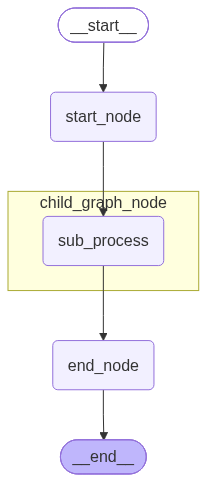

In [37]:
from IPython.display import Image, display

try:
    display(Image(parent_graph.get_graph(xray=True).draw_mermaid_png()))
except Exception as e:
    print(f"Không thể hiển thị sơ đồ: {e}")

##### Bước 4: Thử nghiệm chạy Graph dùng chung State

<small>Kích hoạt chạy parent graph để thấy sự đồng bộ ghi nhận state của cả đồ thị cha và con.</small>

In [38]:
res1 = parent_graph.invoke({"value": "Chào bạn", "log": []})
print("Kết quả chạy Parent-Subgraph dùng chung State:")
print(res1)

Kết quả chạy Parent-Subgraph dùng chung State:
{'value': 'Chào bạn -> [xử lý bởi subgraph]', 'log': ['Bắt đầu parent', 'Chạy sub_node', 'Kết thúc parent']}


### 8.2 Parent và subgraph có state khác nhau

<small>Áp dụng khi đồ thị con có cấu trúc dữ liệu State độc lập (Isolated State) để phục vụ cho các logic đóng gói riêng biệt. Đồ thị con được gọi gián tiếp trong một node hàm wrapper chuyển đổi dữ liệu của đồ thị cha.</small>

##### Bước 1: Khởi tạo ParentState & ChildState khác biệt

<small>Khai báo cấu trúc state khác nhau cho Parent và Child, rồi xây dựng đồ thị con <code>compiled_child_graph</code>.</small>

In [39]:
class ParentState(TypedDict):
    parent_input: str
    parent_output: str
    nested_log: list[str]

class ChildState(TypedDict):
    query: str
    answer: str

# Xây dựng Child Graph độc lập
child_builder = StateGraph(ChildState)

def child_node(state: ChildState) -> dict:
    return {"answer": f"Đã giải đáp câu hỏi: '{state['query']}'"}

child_builder.add_node("child_solver", child_node)
child_builder.add_edge(START, "child_solver")
child_builder.add_edge("child_solver", END)
compiled_child_graph = child_builder.compile()

##### Bước 2: Định nghĩa Node wrapper chuyển đổi State & Gọi Child Graph

<small>Tạo Node wrapper <code>call_child_graph</code> trong Parent Graph thực hiện: Lấy dữ liệu của Parent $\rightarrow$ map vào input của Child $\rightarrow$ gọi Child Graph $\rightarrow$ nhận output của Child $\rightarrow$ map ngược lại Parent State.</small>

In [40]:
parent_diff_builder = StateGraph(ParentState)

def call_child_graph(state: ParentState) -> dict:
    print(f"--- [PARENT WRAPPER] Chuyển đổi ParentState sang ChildState ---")
    # Chuyển đổi dữ liệu: parent_input -> query
    child_input = {"query": state["parent_input"]}
    
    # Gọi đồng bộ/bất đồng bộ đồ thị con
    child_output = compiled_child_graph.invoke(child_input)
    print(f"--- [PARENT WRAPPER] Nhận kết quả từ Child Graph: {child_output} ---")
    
    # Chuyển đổi ngược lại: answer -> parent_output
    new_log = state.get("nested_log", []) + ["Gọi đồ thị con hoàn tất"]
    return {
        "parent_output": child_output["answer"],
        "nested_log": new_log
    }

parent_diff_builder.add_node("call_child_node", call_child_graph)
parent_diff_builder.add_edge(START, "call_child_node")
parent_diff_builder.add_edge("call_child_node", END)

parent_diff_graph = parent_diff_builder.compile()

##### Bước 3: Sơ đồ Graph (Child & Parent)

<small>Hiển thị sơ đồ độc lập của Child Graph và Parent Graph. Ở mô hình này, hai sơ đồ hoàn toàn tách biệt về mặt cấu trúc đồ họa.</small>

--- SƠ ĐỒ CHILD GRAPH ---


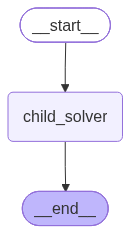


--- SƠ ĐỒ PARENT GRAPH ---


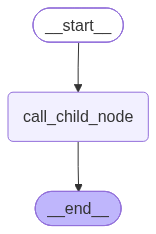

In [41]:
print("--- SƠ ĐỒ CHILD GRAPH ---")
try:
    display(Image(compiled_child_graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Không thể vẽ child graph: {e}")

print("\n--- SƠ ĐỒ PARENT GRAPH ---")
try:
    display(Image(parent_diff_graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Không thể vẽ parent graph: {e}")

##### Bước 4: Thử nghiệm chạy Graph khác State

<small>Kích hoạt parent graph để kiểm chứng việc đóng gói và chuyển dịch trạng thái.</small>

In [42]:
res2 = parent_diff_graph.invoke({
    "parent_input": "Mô hình Subgraph khác state là gì?",
    "parent_output": "",
    "nested_log": []
})
print("Kết quả chạy Parent-Subgraph khác State:")
print(res2)

--- [PARENT WRAPPER] Chuyển đổi ParentState sang ChildState ---
--- [PARENT WRAPPER] Nhận kết quả từ Child Graph: {'query': 'Mô hình Subgraph khác state là gì?', 'answer': "Đã giải đáp câu hỏi: 'Mô hình Subgraph khác state là gì?'"} ---
Kết quả chạy Parent-Subgraph khác State:
{'parent_input': 'Mô hình Subgraph khác state là gì?', 'parent_output': "Đã giải đáp câu hỏi: 'Mô hình Subgraph khác state là gì?'", 'nested_log': ['Gọi đồ thị con hoàn tất']}


# 9. Tool-calling agent bằng LangGraph

<small><b>Tool-calling Agent (Agent gọi công cụ)</b> là mẫu thiết kế cốt lõi trong phát triển ứng dụng AI. 
Mẫu này cho phép LLM quyết định khi nào cần gọi thêm công cụ hỗ trợ ngoài (ví dụ: tìm kiếm web, tra cứu cơ sở dữ liệu) dựa trên câu hỏi của người dùng. 
Luồng hoạt động của agent là một vòng lặp kín (cycle):
1. <b>Agent Node:</b> LLM phân tích câu hỏi và trả về <code>AIMessage</code> chứa yêu cầu gọi công cụ (<code>tool_calls</code>).
2. <b>Router Edge:</b> Cạnh điều kiện kiểm tra xem có yêu cầu gọi công cụ hay không. Nếu có, chuyển sang Tool Node; nếu không, kết thúc luồng.
3. <b>Tool Node:</b> Thực thi công cụ tương ứng và trả kết quả dưới dạng <code>ToolMessage</code> quay lại Agent Node để LLM tổng hợp câu trả lời cuối cùng.</small>

##### Bước 1: Import thư viện & Định nghĩa Tool giả lập

<small>Import các primitive tin nhắn của LangChain (Human, AI, Tool) và định nghĩa hàm công cụ tra cứu thời tiết <code>get_weather</code>.</small>

In [ ]:
import time
from typing import Literal
from langchain_core.messages import HumanMessage, AIMessage, ToolMessage
from langgraph.graph import StateGraph, START, END, MessagesState

# Định nghĩa công cụ tra cứu thời tiết
def get_weather(location: str) -> str:
    loc_lower = location.lower()
    if "hà nội" in loc_lower:
        return "Thời tiết Hà Nội đang là 28 độ C, trời mát, có mây rải rác."
    elif "hồ chí minh" in loc_lower or "tp.hcm" in loc_lower:
        return "Thời tiết TP.HCM đang là 32 độ C, trời nắng nóng, độ ẩm cao."
    else:
        return f"Thời tiết tại {location} hiện tại chưa được cập nhật trong hệ thống."

##### Bước 2: Định nghĩa Node Model (LLM giả lập hỗ trợ Tool-calling)

<small>Node <code>call_model</code> kiểm tra tin nhắn cuối trong State. Nếu là lượt đầu (HumanMessage), quyết định gọi tool. Nếu đã có kết quả tool (ToolMessage), tổng hợp và trả lời người dùng.</small>

In [ ]:
def call_model(state: MessagesState) -> dict:
    messages = state["messages"]
    last_message = messages[-1]
    
    print(f"\n[MODEL NODE] Nhận {len(messages)} tin nhắn trong lịch sử State.")
    
    # Nếu tin nhắn cuối cùng là ToolMessage -> Đọc thông tin từ Tool để tổng hợp trả lời
    if isinstance(last_message, ToolMessage):
        tool_result = last_message.content
        print(f"[MODEL NODE] Đã tiếp nhận dữ liệu từ Tool: '{tool_result}'")
        final_answer = AIMessage(
            content=f"Dựa trên thông tin thời tiết được cung cấp: {tool_result}"
        )
        return {"messages": [final_answer]}
    
    # Nếu tin nhắn cuối cùng là HumanMessage -> Phát sinh yêu cầu gọi Tool
    user_query = last_message.content
    print(f"[MODEL NODE] Câu hỏi của người dùng: '{user_query}'")
    
    if "thời tiết" in user_query.lower():
        location = "Hà Nội"
        if "hồ chí minh" in user_query.lower() or "tp.hcm" in user_query.lower():
            location = "Hồ Chí Minh"
            
        print(f"[MODEL NODE] LLM phân tích và phát lệnh gọi tool 'get_weather' cho địa điểm: '{location}'")
        
        # Trả về AIMessage kèm theo danh sách tool_calls cấu trúc chuẩn
        ai_message = AIMessage(
            content="",
            tool_calls=[{
                "name": "get_weather",
                "args": {"location": location},
                "id": "call_weather_12345"  # Mã định danh cho lượt gọi công cụ
            }]
        )
        return {"messages": [ai_message]}
    
    # Trả lời trực tiếp nếu không cần sử dụng công cụ
    return {"messages": [AIMessage(content="Tôi là chatbot trợ lý thời tiết. Bạn có câu hỏi nào về thời tiết không?")]}

##### Bước 3: Định nghĩa Node thực thi Tool (Tool Node)

<small>Node <code>execute_tools</code> duyệt qua mảng <code>tool_calls</code> trong <code>AIMessage</code> cuối cùng để chạy hàm Python tương ứng và trả về <code>ToolMessage</code>.</small>

In [ ]:
def execute_tools(state: MessagesState) -> dict:
    messages = state["messages"]
    last_message = messages[-1]
    
    print("\n[TOOL NODE] Đang thực thi gọi công cụ ngoài...")
    tool_outputs = []
    
    for tool_call in last_message.tool_calls:
        tool_name = tool_call["name"]
        tool_args = tool_call["args"]
        call_id = tool_call["id"]
        
        print(f"[TOOL NODE] Đang chạy hàm: {tool_name}() với tham số: {tool_args}")
        if tool_name == "get_weather":
            result = get_weather(tool_args["location"])
            tool_msg = ToolMessage(
                content=result,
                name=tool_name,
                tool_call_id=call_id
            )
            tool_outputs.append(tool_msg)
            
    return {"messages": tool_outputs}

##### Bước 4: Thiết lập Hàm Router quyết định hướng đi

<small>Định nghĩa hàm chuyển hướng <code>should_continue</code> dựa trên việc sự xuất hiện của <code>tool_calls</code> trong tin nhắn phản hồi của Model.</small>

In [ ]:
def should_continue(state: MessagesState) -> Literal["tools", "__end__"]:
    messages = state["messages"]
    last_message = messages[-1]
    
    # Nếu tin nhắn cuối chứa yêu cầu gọi tool -> chuyển sang node thực thi tool
    if isinstance(last_message, AIMessage) and last_message.tool_calls:
        print("[ROUTER EDGE] Phát hiện yêu cầu gọi tool -> Rẽ hướng sang Node 'tools'.")
        return "tools"
        
    print("[ROUTER EDGE] Không có yêu cầu gọi tool -> Rẽ hướng sang Node kết thúc 'END'.")
    return END

##### Bước 5: Xây dựng Graph, Cấu hình cạnh điều kiện & Biên dịch

<small>Xây dựng cấu trúc đồ thị tuần hoàn (cyclic graph), liên kết Agent Node với Tool Node qua cạnh điều kiện.</small>

In [ ]:
# 1. Khởi tạo Graph builder sử dụng MessagesState mặc định
builder_agent = StateGraph(MessagesState)

# 2. Thêm các Node chức năng
builder_agent.add_node("agent", call_model)
builder_agent.add_node("tools", execute_tools)

# 3. Thiết lập các cạnh nối
builder_agent.add_edge(START, "agent")

# Cấu hình cạnh điều kiện đi từ agent node
builder_agent.add_conditional_edges(
    "agent",
    should_continue,
    {
        "tools": "tools",
        END: END
    }
)

# Đặt cạnh cố định quay ngược lại agent sau khi gọi xong tool
builder_agent.add_edge("tools", "agent")

# 4. Biên dịch Graph
graph_agent = builder_agent.compile()

##### Bước 6: Sơ đồ Graph Agent

<small>Hiển thị trực quan sơ đồ luồng hoạt động tuần hoàn của Tool-calling Agent.</small>

In [ ]:
from IPython.display import Image, display

try:
    display(Image(graph_agent.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Không thể hiển thị sơ đồ: {e}")

##### Bước 7: Chạy thử nghiệm gửi truy vấn và kiểm chứng luồng đi

<small>Thử nghiệm gửi câu hỏi tra cứu thời tiết TP.HCM. Luồng xử lý sẽ đi qua <code>agent</code> $\rightarrow$ phát hiện gọi tool $\rightarrow$ đi sang <code>tools</code> $\rightarrow$ quay ngược lại <code>agent</code> $\rightarrow$ kết thúc luồng.</small>

In [ ]:
print("=== BẮT ĐẦU CHẠY THỬ NGHIỆM AGENT ===")
final_state = graph_agent.invoke({
    "messages": [HumanMessage(content="Thời tiết ở TP.HCM hôm nay thế nào?")]
})

print("\n=== CHI TIẾT LỊCH SỬ TIN NHẮN (MESSAGE TRACE) ===")
for msg in final_state["messages"]:
    print(f"[{msg.type.upper()}]: {msg.content if msg.content else f'(Gọi Tool: {msg.tool_calls})'}")